In [67]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

from constants import api_key

import time

client = RESTClient(api_key = api_key)

import pyspark
from pyspark.sql.window import Window

import os
import sys

from sklearn.linear_model import LinearRegression, Ridge, Lasso

import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

In [68]:
# spark = (
#     pyspark
#     .sql
#     .SparkSession
#     .builder
#     .appName('sparksession')
#     .config("spark.driver.memory", "8g")
#     .config("spark.executor.memory", "16g")
#     .config("spark.executor.cores", "4")
#     .config("spark.network.timeout", "600s") \
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")  # Only show errors, suppress warnings and info

In [70]:
ticker = 'TTD'
price_performance = collections.defaultdict(list)

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="day", from_="2022-10-16", to="2025-03-03", limit=50000)):
    #if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
    price_performance['Open'].append(agg.open)
    price_performance['Close'].append(agg.close)
    price_performance['high'].append(agg.high)
    price_performance['low'].append(agg.low)
    price_performance['volume'].append(agg.volume)
    price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
    price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)

594it [00:00, 6986.25it/s]


In [71]:
ticker_hist['logReturns_5'] = np.log(ticker_hist['Open']/ticker_hist['Open'].shift(5))
ticker_hist['logReturns_3'] = np.log(ticker_hist['Open']/ticker_hist['Open'].shift(3))
ticker_hist['logReturns_40'] = np.log(ticker_hist['Open']/ticker_hist['Open'].shift(40))

ticker_hist['logReturns_1'] = np.log(ticker_hist['Open']/ticker_hist['Open'].shift(1))

In [72]:
ticker_hist['rolling_mean_5'] = ticker_hist['Open'].rolling(5).mean()
ticker_hist['rolling_mean_20'] = ticker_hist['Open'].rolling(20).mean()
ticker_hist['rolling_mean_40'] = ticker_hist['Open'].rolling(40).mean()


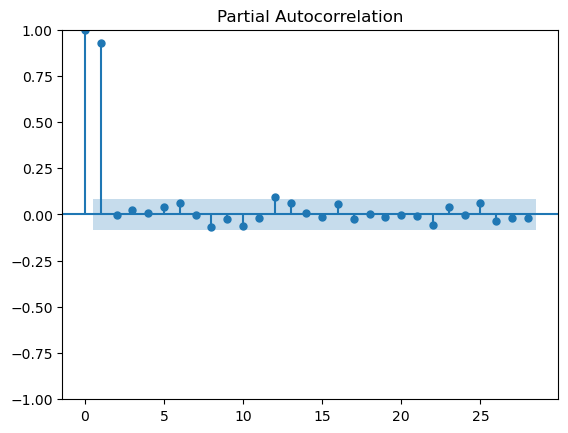

In [73]:
statsmodels.graphics.tsaplots.plot_pacf(
    ticker_hist['logReturns_40'][40:]
)
plt.show()

(540.0, 594.0)

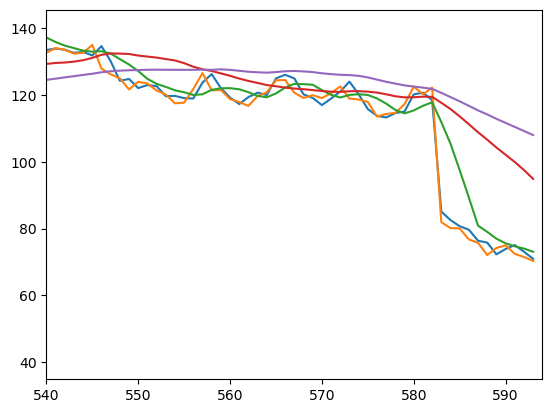

In [75]:
plt.plot(ticker_hist['Open'])
plt.plot(ticker_hist['Close'])
plt.plot(ticker_hist['rolling_mean_5'])
plt.plot(ticker_hist['rolling_mean_20'])
plt.plot(ticker_hist['rolling_mean_40'])
plt.xlim(540, 594)

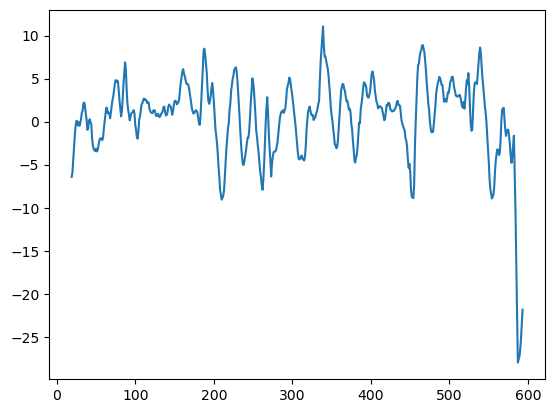

In [76]:
plt.plot( ticker_hist['rolling_mean_5'] - ticker_hist['rolling_mean_20'])

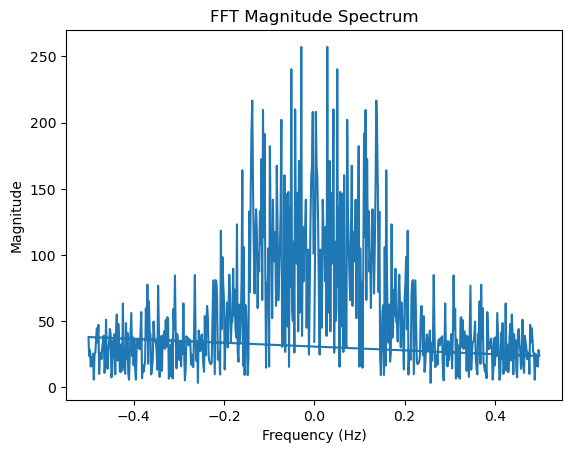

In [66]:
import numpy as np

# Create a sample signal


# Compute the FFT
fft_result = np.fft.fft((ticker_hist['rolling_mean_5'] - ticker_hist['Open']).dropna())

# Get the frequencies corresponding to the FFT coefficients
frequencies = np.fft.fftfreq(len((ticker_hist['rolling_mean_5'] - ticker_hist['Open']).dropna()), 1) 

# Magnitude spectrum
magnitude = np.abs(fft_result) 

# Plot the magnitude spectrum
import matplotlib.pyplot as plt

plt.plot(frequencies, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT Magnitude Spectrum")
plt.show()

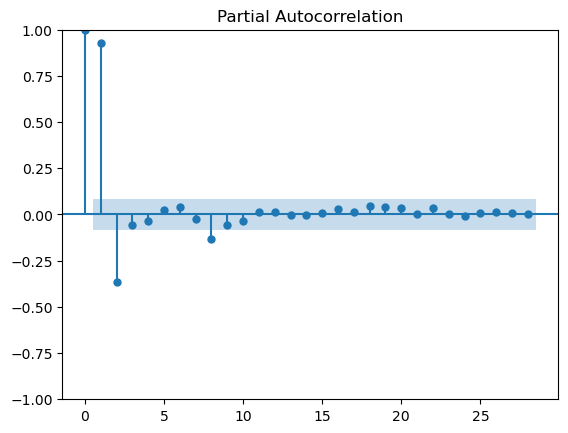

In [47]:
statsmodels.graphics.tsaplots.plot_pacf(
    (ticker_hist['rolling_mean_20'] - ticker_hist['rolling_mean_5']).loc[19:]
)
plt.show()

In [21]:
ticker_hist.iloc[-11:]

,Open,Close,high,low,volume,Datetime,transactions,logReturns_5,logReturns_1
578,114.600,114.65,116.5400,113.420,3328445.0,2025-02-06,53098,-0.078995,0.011497
579,115.100,117.29,117.6300,115.050,4537747.0,2025-02-07,68617,-0.043938,0.004354
580,120.220,122.54,125.8000,119.600,6064485.0,2025-02-10,82612,0.037545,0.043522
581,120.700,120.21,122.4900,119.400,4901916.0,2025-02-11,69998,0.059217,0.003985
582,118.530,122.23,122.4600,118.000,11454460.0,2025-02-12,148071,0.045215,-0.018142
583,85.095,81.92,85.1800,80.655,55947805.0,2025-02-13,535715,-0.297680,-0.331398
584,82.550,80.16,83.6100,80.100,19171132.0,2025-02-14,208835,-0.332397,-0.030364
585,80.700,80.03,80.7500,77.610,16121869.0,2025-02-18,176317,-0.398585,-0.022666
586,79.660,76.75,79.6800,76.635,14196175.0,2025-02-19,151211,-0.415541,-0.012971
587,76.365,75.73,76.4913,74.100,13450720.0,2025-02-20,155305,-0.439642,-0.042243


In [151]:
np.log(ticker_hist['Open'].iloc[11]/ticker_hist['Open'].iloc[6])

np.float64(-0.018240849101790496)

In [152]:
ticker_hist.dropna()

,Open,Close,high,low,volume,Datetime,transactions,logReturns_5,logReturns_1
5,57.250,55.67,57.3000,53.9800,3750283.0,2022-10-24,44393,0.079781,0.053088
6,56.430,57.84,58.5300,56.4300,4325085.0,2022-10-25,48895,-0.001417,-0.014427
7,54.720,55.36,57.2500,53.1764,6906999.0,2022-10-26,84751,-0.022944,-0.030772
8,55.670,53.76,56.3750,53.1300,4886973.0,2022-10-27,63524,0.008841,0.017212
9,53.040,53.71,53.9000,52.3200,4369873.0,2022-10-28,70735,-0.023294,-0.048395
...,...,...,...,...,...,...,...,...,...
583,85.095,81.92,85.1800,80.6550,55947805.0,2025-02-13,535715,-0.297680,-0.331398
584,82.550,80.16,83.6100,80.1000,19171132.0,2025-02-14,208835,-0.332397,-0.030364
585,80.700,80.03,80.7500,77.6100,16121869.0,2025-02-18,176317,-0.398585,-0.022666
586,79.660,76.75,79.6800,76.6350,14196676.0,2025-02-19,151213,-0.415541,-0.012971


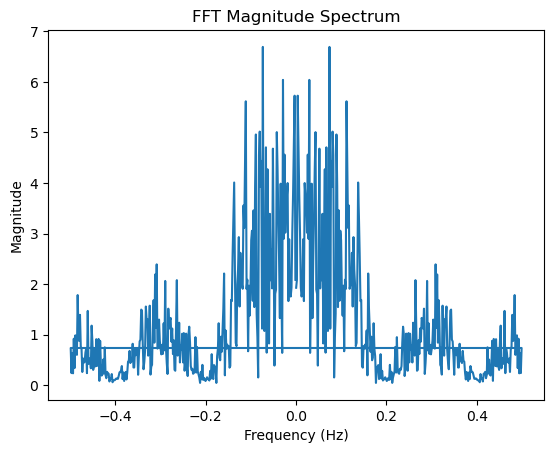

In [153]:
import numpy as np

# Create a sample signal


# Compute the FFT
fft_result = np.fft.fft(ticker_hist['logReturns_5'].dropna())

# Get the frequencies corresponding to the FFT coefficients
frequencies = np.fft.fftfreq(len(ticker_hist['logReturns_5'].dropna()), 1) 

# Magnitude spectrum
magnitude = np.abs(fft_result) 

# Plot the magnitude spectrum
import matplotlib.pyplot as plt

plt.plot(frequencies, magnitude)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT Magnitude Spectrum")
plt.show()

In [154]:
from sklearn.linear_model import LinearRegression, Ridge

In [155]:
ticker_hist['target'] = ticker_hist['logReturns_1'].shift(-1)


In [171]:
ticker_hist.tail(10)

,Open,Close,high,low,volume,Datetime,transactions,logReturns_5,logReturns_1,target,logReturns_5_shift5,logReturns_5_shift4,logReturns_5_shift3,logReturns_5_shift2,logReturns_5_shift1
578,114.600,114.65,116.5400,113.420,3328445.0,2025-02-06,53098,-0.078995,0.011497,-0.043938,0.031203,0.009440,-0.010310,-0.044612,-0.066335
579,115.100,117.29,117.6300,115.050,4537747.0,2025-02-07,68617,-0.043938,0.004354,0.037545,0.009440,-0.010310,-0.044612,-0.066335,-0.078995
580,120.220,122.54,125.8000,119.600,6064485.0,2025-02-10,82612,0.037545,0.043522,0.059217,-0.010310,-0.044612,-0.066335,-0.078995,-0.043938
581,120.700,120.21,122.4900,119.400,4901916.0,2025-02-11,69998,0.059217,0.003985,0.045215,-0.044612,-0.066335,-0.078995,-0.043938,0.037545
582,118.530,122.23,122.4600,118.000,11454460.0,2025-02-12,148071,0.045215,-0.018142,-0.297680,-0.066335,-0.078995,-0.043938,0.037545,0.059217
583,85.095,81.92,85.1800,80.655,55947805.0,2025-02-13,535715,-0.297680,-0.331398,-0.332397,-0.078995,-0.043938,0.037545,0.059217,0.045215
584,82.550,80.16,83.6100,80.100,19171132.0,2025-02-14,208835,-0.332397,-0.030364,-0.398585,-0.043938,0.037545,0.059217,0.045215,-0.297680
585,80.700,80.03,80.7500,77.610,16121869.0,2025-02-18,176317,-0.398585,-0.022666,-0.415541,0.037545,0.059217,0.045215,-0.297680,-0.332397
586,79.660,76.75,79.6800,76.635,14196676.0,2025-02-19,151213,-0.415541,-0.012971,-0.439642,0.059217,0.045215,-0.297680,-0.332397,-0.398585
587,76.365,75.73,76.4913,74.100,13450672.0,2025-02-20,155306,-0.439642,-0.042243,NaN,0.045215,-0.297680,-0.332397,-0.398585,-0.415541


In [175]:
ticker_hist['target'] = ticker_hist['logReturns_5'].shift(-1)
ticker_hist['logReturns_5_shift5'] = ticker_hist['logReturns_5'].shift(5)
ticker_hist['logReturns_5_shift4'] = ticker_hist['logReturns_5'].shift(4)
ticker_hist['logReturns_5_shift3'] = ticker_hist['logReturns_5'].shift(3)
ticker_hist['logReturns_5_shift2'] = ticker_hist['logReturns_5'].shift(2)
ticker_hist['logReturns_5_shift1'] = ticker_hist['logReturns_5'].shift(1)


In [176]:
ticker_hist.tail(15)

,Open,Close,high,low,volume,Datetime,transactions,logReturns_5,logReturns_1,target,logReturns_5_shift5,logReturns_5_shift4,logReturns_5_shift3,logReturns_5_shift2,logReturns_5_shift1
573,124.020,118.94,124.5200,118.5800,3181348.0,2025-01-30,52218,0.031203,0.024157,0.009440,-0.004234,-0.007276,-0.066225,-0.058134,-0.032027
574,120.270,118.68,121.4500,118.0200,3045075.0,2025-01-31,51170,0.009440,-0.030704,-0.010310,-0.007276,-0.066225,-0.058134,-0.032027,0.031203
575,115.790,117.94,119.7900,115.0000,3479894.0,2025-02-03,54942,-0.010310,-0.037961,-0.044612,-0.066225,-0.058134,-0.032027,0.031203,0.009440
576,113.760,113.54,115.7600,112.4901,6106033.0,2025-02-04,81204,-0.044612,-0.017687,-0.066335,-0.058134,-0.032027,0.031203,0.009440,-0.010310
577,113.290,114.34,114.4600,113.0600,4455436.0,2025-02-05,54549,-0.066335,-0.004140,-0.078995,-0.032027,0.031203,0.009440,-0.010310,-0.044612
578,114.600,114.65,116.5400,113.4200,3328445.0,2025-02-06,53098,-0.078995,0.011497,-0.043938,0.031203,0.009440,-0.010310,-0.044612,-0.066335
579,115.100,117.29,117.6300,115.0500,4537747.0,2025-02-07,68617,-0.043938,0.004354,0.037545,0.009440,-0.010310,-0.044612,-0.066335,-0.078995
580,120.220,122.54,125.8000,119.6000,6064485.0,2025-02-10,82612,0.037545,0.043522,0.059217,-0.010310,-0.044612,-0.066335,-0.078995,-0.043938
581,120.700,120.21,122.4900,119.4000,4901916.0,2025-02-11,69998,0.059217,0.003985,0.045215,-0.044612,-0.066335,-0.078995,-0.043938,0.037545
582,118.530,122.23,122.4600,118.0000,11454460.0,2025-02-12,148071,0.045215,-0.018142,-0.297680,-0.066335,-0.078995,-0.043938,0.037545,0.059217


In [177]:
lr = LinearRegression()
lr.fit(ticker_hist.dropna()[['logReturns_5_shift1']], ticker_hist.dropna()['target'])
print(lr.score(ticker_hist.dropna()[['logReturns_5_shift1']], ticker_hist.dropna()['target']))

lr.fit(ticker_hist.dropna()[['logReturns_5', 'logReturns_5_shift1']], ticker_hist.dropna()['target'])
lr.score(ticker_hist.dropna()[['logReturns_5', 'logReturns_5_shift1']], ticker_hist.dropna()['target'])



0.26719569218118266


0.5948348993868725

In [123]:
ticker_hist.dropna()[
        [

            'logReturns_5_shift1',
            'logReturns_5_shift2',
            'logReturns_5_shift3',
            'logReturns_5_shift4',
            'logReturns_5_shift5'
        ]
].loc[]

SyntaxError: invalid syntax (2157899327.py, line 10)

In [180]:
from sklearn.ensemble import RandomForestRegressor

rfr = LinearRegression()
rfr.fit(
    ticker_hist.dropna()[
        [
            'logReturns_5',
            'logReturns_5_shift1',
            'logReturns_5_shift2',
            'logReturns_5_shift3',
            'logReturns_5_shift4',
            'logReturns_5_shift5'
        ]
    ].iloc[:-100], 
    ticker_hist.dropna()['target'].iloc[:-100]
)
print(
    rfr.score(
        ticker_hist.dropna()[
            [
                'logReturns_5',
                'logReturns_5_shift1',
                'logReturns_5_shift2',
                'logReturns_5_shift3',
                'logReturns_5_shift4',
                'logReturns_5_shift5'
            ]
        ].iloc[:-100], 
        ticker_hist.dropna()['target'].iloc[:-100]
    )
)

print(
    rfr.score(
        ticker_hist.dropna()[
            [ 
                'logReturns_5',
                'logReturns_5_shift1',
                'logReturns_5_shift2',
                'logReturns_5_shift3',
                'logReturns_5_shift4',
                'logReturns_5_shift5'
            ]
        ].iloc[-100:], 
        ticker_hist.dropna()['target'].iloc[-100:]
    )
)


0.6556082983407692
0.72937693706258


In [181]:
rfr.coef_

array([ 0.81187071,  0.0177562 ,  0.03917766, -0.10398566, -0.45631234,
        0.39761047])

In [183]:
(ticker_hist[
                ['logReturns_5', 
                'logReturns_5_shift1',
                'logReturns_5_shift2',
                'logReturns_5_shift3',
                'logReturns_5_shift4',
                'logReturns_5_shift5']
            ].loc[587].values * rfr.coef_).sum() + rfr.intercept_

np.float64(-0.18929474739368982)

In [127]:
np.log(99/120)

np.float64(-0.19237189264745613)

In [182]:
ticker_hist.tail(15)

,Open,Close,high,low,volume,Datetime,transactions,logReturns_5,logReturns_1,target,logReturns_5_shift5,logReturns_5_shift4,logReturns_5_shift3,logReturns_5_shift2,logReturns_5_shift1
573,124.020,118.94,124.5200,118.5800,3181348.0,2025-01-30,52218,0.031203,0.024157,0.009440,-0.004234,-0.007276,-0.066225,-0.058134,-0.032027
574,120.270,118.68,121.4500,118.0200,3045075.0,2025-01-31,51170,0.009440,-0.030704,-0.010310,-0.007276,-0.066225,-0.058134,-0.032027,0.031203
575,115.790,117.94,119.7900,115.0000,3479894.0,2025-02-03,54942,-0.010310,-0.037961,-0.044612,-0.066225,-0.058134,-0.032027,0.031203,0.009440
576,113.760,113.54,115.7600,112.4901,6106033.0,2025-02-04,81204,-0.044612,-0.017687,-0.066335,-0.058134,-0.032027,0.031203,0.009440,-0.010310
577,113.290,114.34,114.4600,113.0600,4455436.0,2025-02-05,54549,-0.066335,-0.004140,-0.078995,-0.032027,0.031203,0.009440,-0.010310,-0.044612
578,114.600,114.65,116.5400,113.4200,3328445.0,2025-02-06,53098,-0.078995,0.011497,-0.043938,0.031203,0.009440,-0.010310,-0.044612,-0.066335
579,115.100,117.29,117.6300,115.0500,4537747.0,2025-02-07,68617,-0.043938,0.004354,0.037545,0.009440,-0.010310,-0.044612,-0.066335,-0.078995
580,120.220,122.54,125.8000,119.6000,6064485.0,2025-02-10,82612,0.037545,0.043522,0.059217,-0.010310,-0.044612,-0.066335,-0.078995,-0.043938
581,120.700,120.21,122.4900,119.4000,4901916.0,2025-02-11,69998,0.059217,0.003985,0.045215,-0.044612,-0.066335,-0.078995,-0.043938,0.037545
582,118.530,122.23,122.4600,118.0000,11454460.0,2025-02-12,148071,0.045215,-0.018142,-0.297680,-0.066335,-0.078995,-0.043938,0.037545,0.059217


In [140]:
np.exp(np.float64(0.07910768331278388) - np.log(139.51/130.020))*139.51

np.float64(140.72335869716957)

In [70]:
rfr.coef_

array([ 0.39699241, -0.45569616, -0.10565623,  0.04012021,  0.0174226 ,
        0.81172694])

In [66]:
(ticker_hist[
                ['logReturns_5', 
                'logReturns_5_shift1',
                'logReturns_5_shift2',
                'logReturns_5_shift3',
                'logReturns_5_shift4',
                'logReturns_5_shift5']
            ].loc[581].values * rfr.coef_).sum()
           

np.float64(0.22670909992077437)

In [55]:
ticker_hist.tail(10)

,Open,Close,high,low,volume,Datetime,transactions,logReturns_5,logReturns_1,target,logReturns_5_shift5,logReturns_5_shift4,logReturns_5_shift3,logReturns_5_shift2,logReturns_5_shift1
577,113.290,114.34,114.46,113.060,4455436.0,2025-02-05,54549,-0.066335,-0.004140,-0.297680,0.045215,0.059217,0.037545,-0.043938,-0.078995
578,114.600,114.65,116.54,113.420,3328445.0,2025-02-06,53098,-0.078995,0.011497,-0.332397,-0.297680,0.045215,0.059217,0.037545,-0.043938
579,115.100,117.29,117.63,115.050,4537747.0,2025-02-07,68617,-0.043938,0.004354,-0.398585,-0.332397,-0.297680,0.045215,0.059217,0.037545
580,120.220,122.54,125.80,119.600,6064485.0,2025-02-10,82612,0.037545,0.043522,-0.415541,-0.398585,-0.332397,-0.297680,0.045215,0.059217
581,120.700,120.21,122.49,119.400,4901916.0,2025-02-11,69998,0.059217,0.003985,NaN,-0.415541,-0.398585,-0.332397,-0.297680,0.045215
582,118.530,122.23,122.46,118.000,11454460.0,2025-02-12,148071,0.045215,-0.018142,NaN,NaN,-0.415541,-0.398585,-0.332397,-0.297680
583,85.095,81.92,85.18,80.655,55947805.0,2025-02-13,535715,-0.297680,-0.331398,NaN,NaN,NaN,-0.415541,-0.398585,-0.332397
584,82.550,80.16,83.61,80.100,19171132.0,2025-02-14,208835,-0.332397,-0.030364,NaN,NaN,NaN,NaN,-0.415541,-0.398585
585,80.700,80.03,80.75,77.610,16121473.0,2025-02-18,176312,-0.398585,-0.022666,NaN,NaN,NaN,NaN,NaN,-0.415541
586,79.660,76.75,79.68,76.635,14188056.0,2025-02-19,151144,-0.415541,-0.012971,NaN,NaN,NaN,NaN,NaN,NaN


In [195]:
i = 1
np.corrcoef(na_cleaned_ticker_hist['logReturns_5'].iloc[:-i], na_cleaned_ticker_hist['logReturns_5'].iloc[i:])

array([[1.        , 0.75935752],
       [0.75935752, 1.        ]])

In [132]:
ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

times = pd.DataFrame(ticker_hist['Time'].unique())
times.columns = ['Time']
times['Time'] = times['Time'].sort_values().reset_index(drop = True)

ab_params = {}

ab_params['a'] = {}
ab_params['b'] = {}


print('analyzing')

dates = ticker_hist['Date'].unique()

for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

    #ticker_hist_date = pd.merge(left = times, right = ticker_hist_date, on = "Time", how = "outer")
    #ticker_hist_date = ticker_hist_date.sort_values(by = 'Time').reset_index(drop = True)
    #ticker_hist_date = ticker_hist_date.ffill()
    logReturns = ticker_hist_date['logClose'] - ticker_hist_date['logOpen']

    #counts, bin_edges = np.histogram(ticker_hist_date['logReturns'], bins=100)
    a = np.mean(logReturns)
    b = np.sum(
            np.abs(logReturns - a)
    ) / (len(logReturns))
    ab_params['a'][date] = a
    ab_params['b'][date] = b

analyzing


559it [03:58,  2.34it/s]


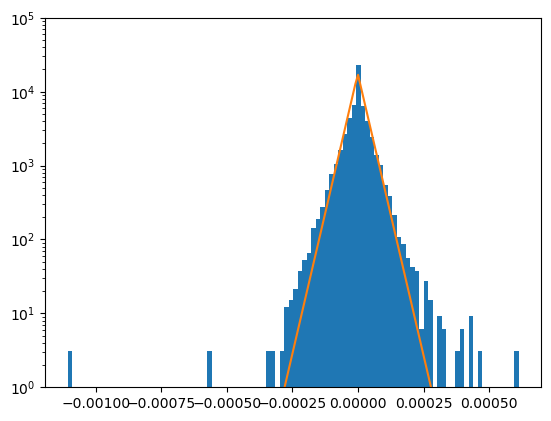

In [133]:
plt.hist(logReturns, bins = 100, density = True)

plt.plot(
    np.arange(-0.0004, 0.0004, 0.00001),
    1 / (2*b) * np.exp(
        - np.abs(
            np.arange(-0.0004, 0.0004, 0.00001) - a
        )/(b)
    )
)
plt.ylim(10**0, 10**5)
plt.yscale('log')
plt.show()

In [134]:
a

np.float64(-1.0298999298090847e-06)

In [135]:
mu = np.mean(logReturns)

In [136]:
sigma = np.std(logReturns)

In [137]:
np.mean((logReturns - mu)**3)/sigma**3

np.float64(-0.45230352280899655)

In [138]:
np.mean((logReturns - mu)**4)/sigma**4

np.float64(26.99720800419468)

In [82]:
autocorrs = []
for index, date in tqdm(enumerate(dates)):
    ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

    ticker_hist_date = pd.merge(left = times, right = ticker_hist_date, on = "Time", how = "outer")
    ticker_hist_date = ticker_hist_date.sort_values(by = 'Time').reset_index(drop = True)
    ticker_hist_date = ticker_hist_date.ffill()

    logReturns = ticker_hist_date['logOpen'].diff().dropna()

    autocorrs.append(scipy.stats.pearsonr(logReturns[1:], logReturns[:-1]).statistic)

    

557it [03:02,  3.05it/s]


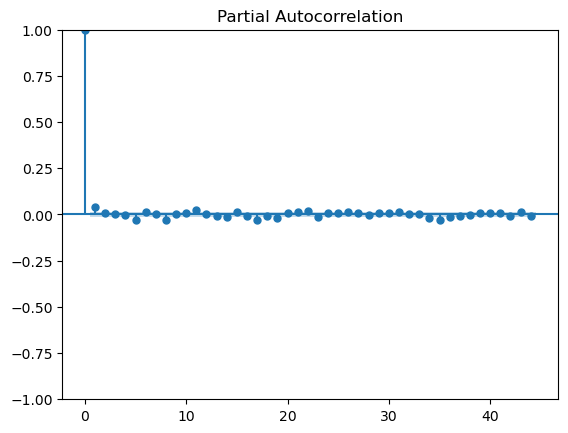

In [83]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    logReturns
)
plt.show()

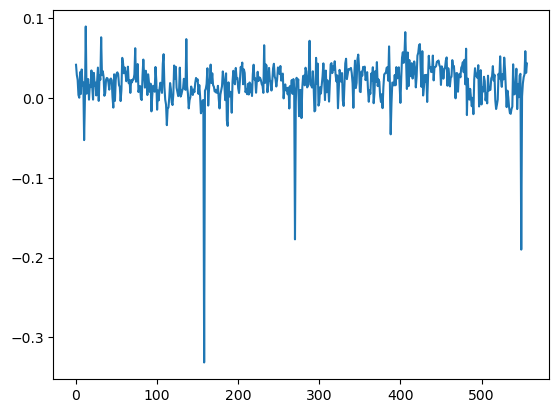

In [84]:
plt.plot(autocorrs)

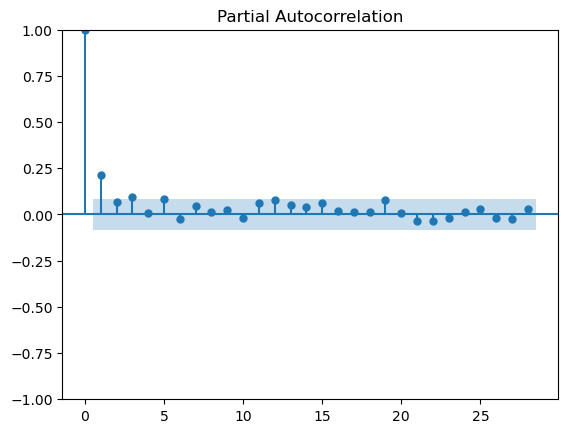

In [85]:
statsmodels.graphics.tsaplots.plot_pacf(
    np.asarray(autocorrs)
)
plt.title("Partial Autocorrelation")
plt.show()

(0.0, 0.4)

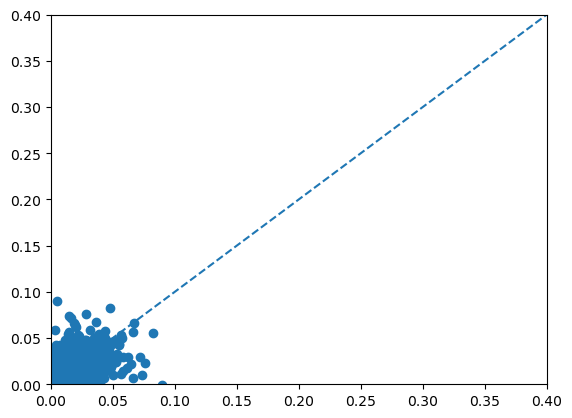

In [86]:
plt.scatter(np.asarray(autocorrs)[1:], np.asarray(autocorrs)[:-1])
plt.plot([-1,1],[-1,1], '--')
plt.xlim([0, 0.4])
plt.ylim([0, 0.4])


In [87]:
ab_params_df = pd.DataFrame(ab_params)
ab_params_df = ab_params_df.dropna()

In [88]:
ab_params_df

,a,b
2022-10-17,0.0,0.000040
2022-10-18,0.0,0.000052
2022-10-19,0.0,0.000046
2022-10-20,0.0,0.000046
2022-10-21,0.0,0.000058
...,...,...
2024-12-27,0.0,0.000026
2024-12-30,0.0,0.000028
2024-12-31,0.0,0.000027
2025-01-02,0.0,0.000040


/Users/hiroku007/miniforge3/envs/algo_trading/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1491: ValueWarning: Matrix is singular. Using pinv.
  warnings.warn("Matrix is singular. Using pinv.", ValueWarning)


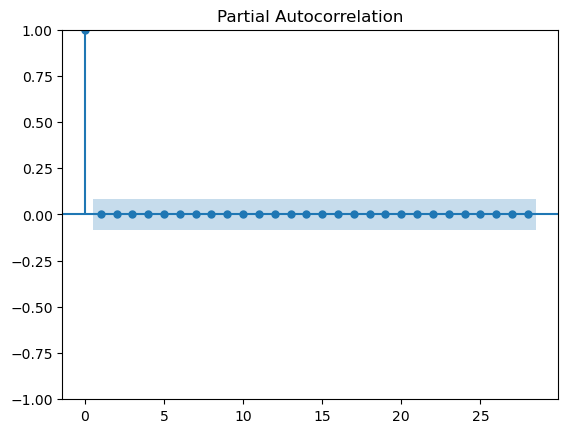

In [89]:
import statsmodels.tsa
import statsmodels
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_pacf

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['a']
)
plt.show()

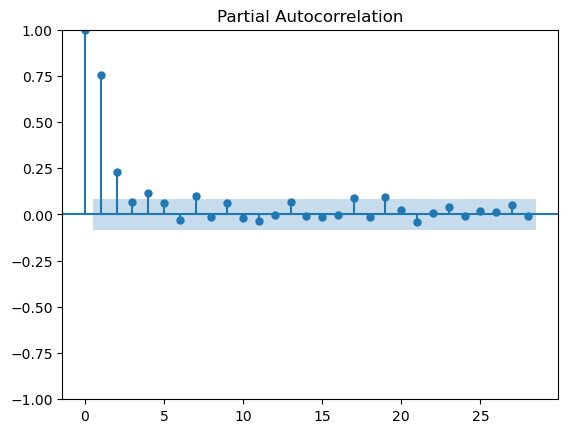

In [90]:
import statsmodels.tsa

statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b']
)
plt.show()

In [91]:
scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_1508/4035013352.py:1: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  scipy.stats.spearmanr(ab_params_df['a'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])


SignificanceResult(statistic=nan, pvalue=nan)

In [92]:
scipy.stats.pearsonr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['b'].iloc[:-1])

PearsonRResult(statistic=np.float64(0.7571608217268884), pvalue=np.float64(1.5714672188854047e-104))

In [93]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-2).iloc[:-2], ab_params_df['b'].iloc[:-2])

SignificanceResult(statistic=np.float64(0.6822538924660837), pvalue=np.float64(3.0181341017616224e-77))

In [94]:
scipy.stats.spearmanr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])

/var/folders/t5/hglcpfcd3px36gr5wgd_4mtm0000gn/T/ipykernel_1508/370312656.py:1: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  scipy.stats.spearmanr(ab_params_df['b'].shift(-1).iloc[:-1], ab_params_df['a'].iloc[:-1])


SignificanceResult(statistic=nan, pvalue=nan)

In [95]:
ab_params_df['shifted_a_1'] = ab_params_df['a'].shift(-1)
ab_params_df['shifted_b_1'] = ab_params_df['b'].shift(-1)



In [96]:
lr_b = LinearRegression()

lr_b.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1'])
print(lr_b.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_b_1']))

lr_a = LinearRegression()

lr_a.fit(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1'])
print(lr_a.score(ab_params_df.dropna()[['a', 'b']], ab_params_df.dropna()['shifted_a_1']))


0.5732925099581367
1.0


In [97]:
ab_params_df['shifted_a_2'] = ab_params_df['a'].shift(-2)
ab_params_df['shifted_b_2'] = ab_params_df['b'].shift(-2)

In [98]:
r_b = LinearRegression()

r_b.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2'])
print(r_b.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_b_2']))

r_a = LinearRegression()

r_a.fit(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2'])
print(r_a.score(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']], ab_params_df.dropna()['shifted_a_2']))


0.5964140837137026
1.0


In [99]:
r_b.coef_

array([0.        , 0.24031399, 0.        , 0.56873193])

In [100]:
lr_b.coef_

array([0.       , 0.7554842])

In [101]:
lr_a.coef_

array([0., 0.])

In [102]:
r_a.coef_

array([0., 0., 0., 0.])

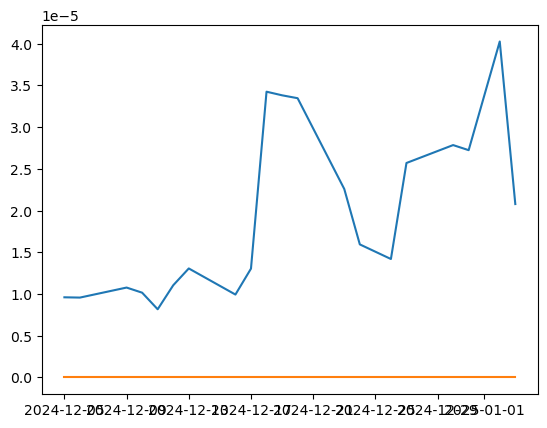

In [103]:
plt.plot(ab_params_df['b'][-20:])
plt.plot(ab_params_df['a'][-20:])


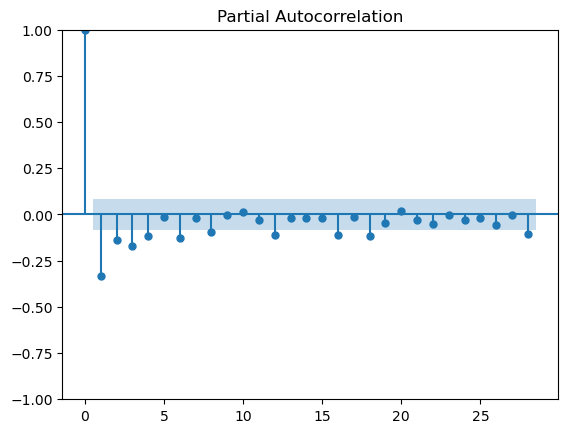

In [104]:
statsmodels.graphics.tsaplots.plot_pacf(
    ab_params_df['b'].diff()[1:]
)
plt.show()

(520.0, 600.0)

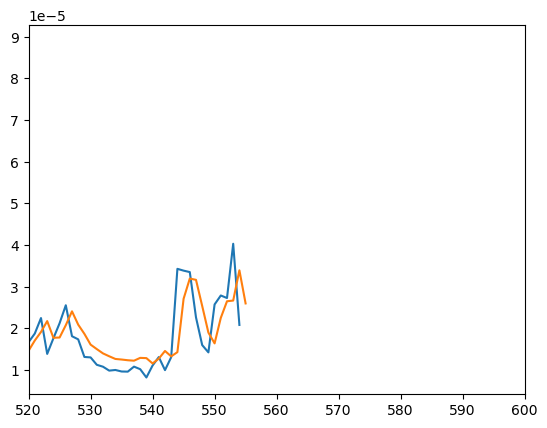

In [105]:
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True))
plt.plot(r_b.predict(ab_params_df[['a', 'b', 'shifted_a_1', 'shifted_b_1']].dropna()))

plt.xlim(520, 600)

(332.0, 453.0)

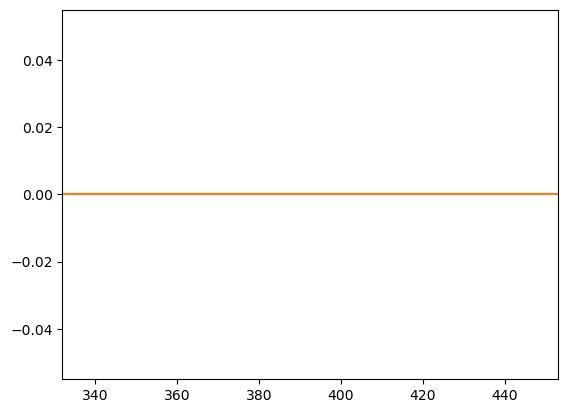

In [106]:
plt.plot(ab_params_df.dropna()['shifted_a_2'].reset_index(drop=True))
plt.plot(r_a.predict(ab_params_df.dropna()[['a', 'b', 'shifted_a_1', 'shifted_b_1']]))

plt.xlim(332,453)

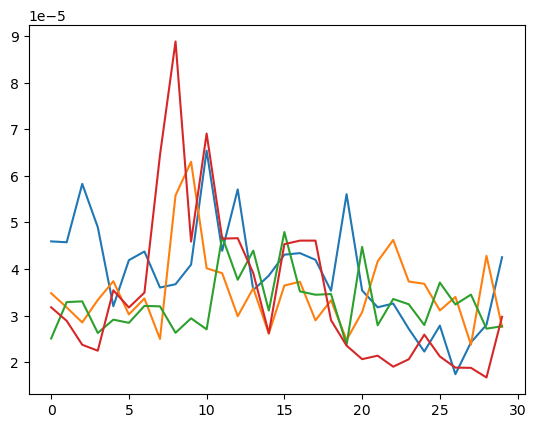

In [107]:
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True)[:30].reset_index(drop = True))
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True)[30:60].reset_index(drop = True))
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True)[60:90].reset_index(drop = True))
plt.plot(ab_params_df.dropna()['shifted_b_2'].reset_index(drop=True)[90:120].reset_index(drop = True))


In [108]:
replicates = 100000

In [109]:
possible_final_returns = np.zeros(replicates)
for r in tqdm(range(replicates)):
    samples = np.random.laplace(
        loc=r_a.predict(ab_params_df[
            ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1], 
        scale=r_b.predict(
            ab_params_df[
                ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1],
        size=len(ticker_hist_date)
    )

    possible_final_returns[r] = samples.sum()


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [02:17<00:00, 728.07it/s]


In [110]:
len(ticker_hist_date)

23401

In [111]:
6.5*3600

23400.0

In [112]:
np.std(possible_final_returns)

np.float64(0.005601077055544042)

In [113]:
r_a.predict(ab_params_df[
            ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1]

np.float64(0.0)

In [114]:
r_b.predict(
            ab_params_df[
                ['a', 'b', 'shifted_a_1', 'shifted_b_1']
            ].dropna()
        )[-1]

np.float64(2.5947413214422708e-05)

# declare spot ticker price

In [115]:
spot_spx_price = 5868.

In [116]:
possible_final_prices = spot_spx_price * np.exp(np.asarray(possible_final_returns))

In [117]:
print(np.mean(possible_final_prices))
print(np.std(possible_final_prices))

5868.020394168659
32.86750079393886


In [118]:
upper_call = 6125.
lower_call = 6120.
upper_put = 6060.
lower_put = 6055.

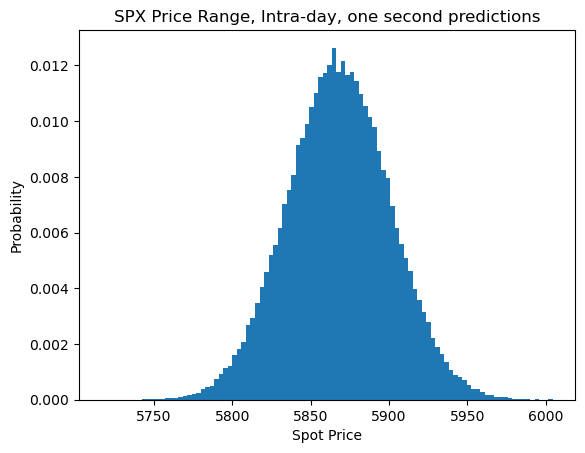

In [119]:
plt.hist(possible_final_prices, bins = 100, density = True)
plt.ylabel('Probability')
plt.xlabel('Spot Price')
plt.title('SPX Price Range, Intra-day, one second predictions')
#plt.savefig('end_price_distro_t2.pdf', bbox_inches = 'tight')
plt.show()

In [51]:
payouts = np.zeros(replicates)
for index, price in enumerate(possible_final_prices):
    payout = (
        np.max([0., lower_put - price])
        - np.max([0., upper_put - price])
        - np.max([0., price - lower_call])
        + np.max([0., price - upper_call])
    )

    payouts[index] = payout

Text(0.5, 1.0, 'avg payout is -5.0')

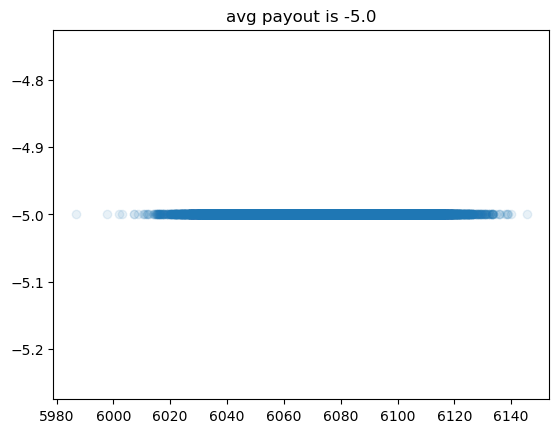

In [52]:
plt.scatter(possible_final_prices, payouts, alpha=0.1)
mean_payout = np.round(np.mean(payouts), 2)
plt.title(f'avg payout is {mean_payout}')

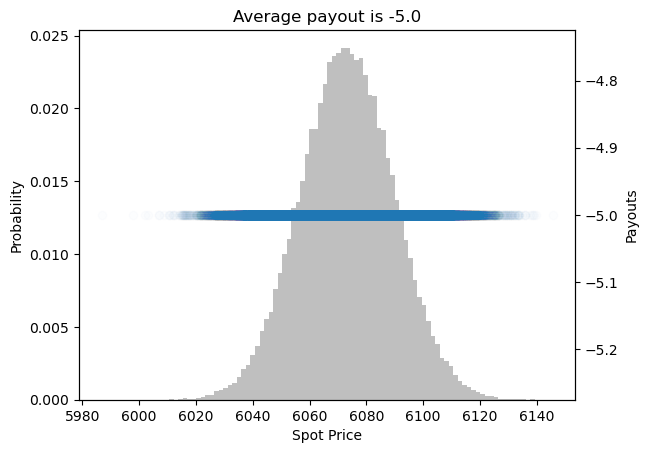

In [53]:
fig, axs = plt.subplots()

axs.hist(possible_final_prices, bins = 100, density = True, alpha=0.5, color = 'grey')
axs.set_ylabel('Probability')
axs.set_xlabel('Spot Price')
#axs.set_title('SPX Price Range, Intra-day, one second predictions')
axs_right = axs.twinx()
#plt.savefig('end_price_distro.pdf', bbox_inches = 'tight')
axs_right.scatter(possible_final_prices, payouts,  alpha=0.01)
axs_right.set_ylabel('Payouts')
mean_payout = np.round(np.mean(payouts), 2)
axs.set_title(f'Average payout is {mean_payout}')
#plt.savefig('with_strategy.png', bbox_inches = 'tight')

plt.show()

# compute cost of trade and max loss

In [233]:
cost_of_trade = 0.7
max_loss = 5

In [234]:
p = (max_loss - cost_of_trade)/max_loss

In [235]:
fstar = p - (1-p)/(cost_of_trade/(max_loss-cost_of_trade))
print(f'Kelly Criterion prediction, assuming fair odds, is {fstar}')

Kelly Criterion prediction, assuming fair odds, is -2.220446049250313e-16


In [236]:
my_p = sum(payouts > -cost_of_trade)/len(payouts)

fstar_me = my_p - (1 - my_p)/(cost_of_trade/(max_loss-cost_of_trade))

print(f'Kelly Criterion prediction, assuming my odds, is {fstar_me}')

Kelly Criterion prediction, assuming my odds, is 0.6766428571428569
